# Data Wrangling, II — Academic Performance Dataset

**Assignment Objective:** Create an academic performance dataset and:
1. Scan all variables for **missing values and inconsistencies** and handle them.
2. Scan all numeric variables for **outliers** and handle them.
3. Apply **data transformations** on at least one variable to reduce skewness or rescale.

We use a synthetic Academic Performance dataset of 50 students. The dataset has been deliberately seeded with realistic data-quality problems so each technique below has something concrete to fix:
- Inconsistent gender labels (`M`, `Male`, `male`, `MALE`, `F`, `Female`, `female`, `FEMALE`)
- Missing values in `Age`, `Math_Score`, `Reading_Score`, `Placement_Score`, `Attendance`
- Out-of-range values (negative age, age = 150, scores > 100, attendance > 100)
- Outliers in `Math_Score` and `Study_Hours`
- A right-skewed `Study_Hours` distribution (perfect for log transformation)

Data Wrangling II (Academic Performance Dataset)
Big picture: Where Notebook 1 dealt with missing and miscoded data, this one deals with two harder problems — outliers (values that are technically valid but suspicious) and skewed distributions (data that isn't symmetric and breaks many statistical methods).
What we did, step by step:

Brought in our toolbox — Same libraries as before, plus a statistics library for measuring skewness and detecting outliers.
Loaded the dataset — A 50-student academic performance table with columns for gender, age, class year, multiple test scores, attendance percentage, and weekly study hours.
Hunted for missing values — Counted empty cells per column and visualized the missing pattern as a heatmap. Filled them with the median (robust to extreme values).
Hunted for inconsistencies — Two distinct kinds:

Format inconsistencies — The "Gender" column had eight different spellings of the same two ideas (M, Male, male, MALE, F, Female, female, FEMALE). We standardized everything to just Male and Female by lowercasing first, then mapping to clean labels.
Out-of-range values — Ages of −3 or 150, test scores above 100, attendance above 100%. These are physically impossible. We replaced them with "missing" and re-imputed with the median.


Hunted for outliers — These are values that fall far from the rest of the data without being technically invalid. We used two complementary approaches:

Visually — drew a boxplot for each numeric column. Boxplots show the middle 50% as a box, with dots for any value too far above or below the box.
Mathematically — used the IQR rule: compute the gap between the 25th and 75th percentile, then flag anything more than 1.5× that gap above the top or below the bottom.


Treated the outliers — Instead of deleting outlier rows (which would shrink our small dataset), we capped them. Any value above the upper boundary got replaced with the boundary value; same for the lower side. This is called winsorization.

We also showed the Z-score method as an alternative: compute how many standard deviations each value is from the mean, and anything beyond ±3 is an outlier.


Tackled skewness with a transformation — The "Study Hours" column was right-skewed: most students studied a normal amount, but a few studied 30+ hours a week, dragging the average up.

Why this matters: Many statistical techniques (regression, t-tests, ANOVA) assume the data is roughly bell-shaped. Skewed data breaks those assumptions.
The fix: apply a log transformation. The log function compresses large values much more than small ones, which pulls in the long tail and pushes the distribution toward a bell shape. We measured the skewness number before and after to confirm it dropped toward zero.
Also showed alternative transformations for reference: square root (mild fix), Min-Max scaling (rescale to 0–1), and Z-score standardization (mean of 0, spread of 1).


Saved the cleaned, transformed table — Ready for analysis or modeling.

## Step 1: Import Required Libraries

In [1]:
# pandas — primary library for data manipulation; provides the DataFrame.
import pandas as pd

# numpy — numerical computing; we use np.nan for missing values and np.log for transformations.
import numpy as np

# matplotlib.pyplot — basic plotting (boxplots, histograms).
import matplotlib.pyplot as plt

# seaborn — statistical visualization built on matplotlib; cleaner boxplots and distplots.
import seaborn as sns

# scipy.stats — provides skew(), zscore(), and statistical tests.
# - skew() measures how asymmetric a distribution is (0 = symmetric).
# - zscore() expresses each value as standard deviations from the mean.
from scipy import stats

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

# Make plots appear inline and look nicer
sns.set_style('whitegrid')
%matplotlib inline

print("All libraries imported successfully.")

All libraries imported successfully.


## Step 2: Load the Academic Performance Dataset

The dataset (`academic_performance.csv`) is loaded from the same folder as this notebook.

### Variable Descriptions

| Variable | Description | Type |
|----------|-------------|------|
| `Roll_No` | Unique student roll number | Integer |
| `Name` | Student name | String |
| `Gender` | Gender (deliberately inconsistent labels) | String (categorical) |
| `Age` | Age in years | Float |
| `Class` | Year of study (FY/SY/TY/BE) | String (categorical) |
| `Math_Score` | Mathematics test score (0–100) | Float |
| `Reading_Score` | Reading test score (0–100) | Float |
| `Writing_Score` | Writing test score (0–100) | Float |
| `Placement_Score` | Placement test score (0–100) | Float |
| `Attendance` | Attendance percentage (0–100) | Float |
| `Study_Hours` | Study hours per week | Float |

In [2]:
# read_csv() reads a comma-separated file into a pandas DataFrame.
df = pd.read_csv('Data_Wrangling_II.csv')

# shape returns (rows, columns)
print("Shape:", df.shape)

# head() shows the first 5 rows for a quick visual check
df.head()

Shape: (50, 11)


,Roll_No,Name,Gender,Age,Class,Math_Score,Reading_Score,Writing_Score,Placement_Score,Attendance,Study_Hours
0,1,Student_001,F,22.0,FY,67.3,59.1,71.2,46.9,66.7,7.49
1,2,Student_002,MALE,19.0,SY,63.8,60.1,79.9,15.0,88.5,9.20
2,3,Student_003,Female,20.0,BE,87.7,73.2,70.4,25.5,105.0,10.94
3,4,Student_004,F,20.0,FY,NaN,66.8,51.0,46.0,97.6,3.37
4,5,Student_005,M,17.0,BE,82.5,64.1,82.7,60.6,75.7,2.84


In [3]:
# info() — concise summary: column names, non-null counts, data types, memory usage.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Roll_No          50 non-null     int64  
 1   Name             50 non-null     str    
 2   Gender           50 non-null     str    
 3   Age              49 non-null     float64
 4   Class            50 non-null     str    
 5   Math_Score       48 non-null     float64
 6   Reading_Score    48 non-null     float64
 7   Writing_Score    50 non-null     float64
 8   Placement_Score  49 non-null     float64
 9   Attendance       48 non-null     float64
 10  Study_Hours      50 non-null     float64
dtypes: float64(7), int64(1), str(3)
memory usage: 4.4 KB


In [4]:
# describe() — summary statistics for numeric columns.
# Pay attention to min and max — values outside the valid range hint at inconsistencies.
df.describe()

,Roll_No,Age,Math_Score,Reading_Score,Writing_Score,Placement_Score,Attendance,Study_Hours
count,50.00000,49.000000,48.000000,48.000000,50.000000,49.000000,48.000000,50.000000
mean,25.50000,21.938776,69.808333,73.325000,70.906000,33.048980,81.100000,8.128200
std,14.57738,19.024554,17.849451,10.925405,12.451545,25.138733,12.504586,7.467002
min,1.00000,-3.000000,5.000000,54.700000,48.300000,5.000000,62.200000,0.650000
25%,13.25000,18.000000,63.950000,64.850000,61.025000,15.000000,72.175000,3.935000
50%,25.50000,20.000000,70.000000,71.950000,70.800000,26.200000,81.350000,6.195000
75%,37.75000,21.000000,81.375000,81.225000,80.275000,46.000000,90.350000,10.055000
max,50.00000,150.000000,105.000000,100.000000,100.000000,99.000000,110.000000,42.000000


## Step 3: Scan for Missing Values and Inconsistencies

We tackle this in two parts:
- **3.1 Missing values** — `NaN` cells detected with `isnull()`.
- **3.2 Inconsistencies** — values that are present but invalid (wrong format, out-of-range, etc.).

### 3.1 Missing Values

In [5]:
# isnull() returns a True/False mask of the same shape as df.
# Summing booleans (True=1, False=0) per column counts missing entries.
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Roll_No            0
Name               0
Gender             0
Age                1
Class              0
Math_Score         2
Reading_Score      2
Writing_Score      0
Placement_Score    1
Attendance         2
Study_Hours        0
dtype: int64


In [6]:
# Percentage of missing values — helps decide whether to drop or impute.
missing_pct = (df.isnull().sum() / len(df)) * 100
print("Percentage of missing values per column:")
print(missing_pct.round(2))

Percentage of missing values per column:
Roll_No            0.0
Name               0.0
Gender             0.0
Age                2.0
Class              0.0
Math_Score         4.0
Reading_Score      4.0
Writing_Score      0.0
Placement_Score    2.0
Attendance         4.0
Study_Hours        0.0
dtype: float64


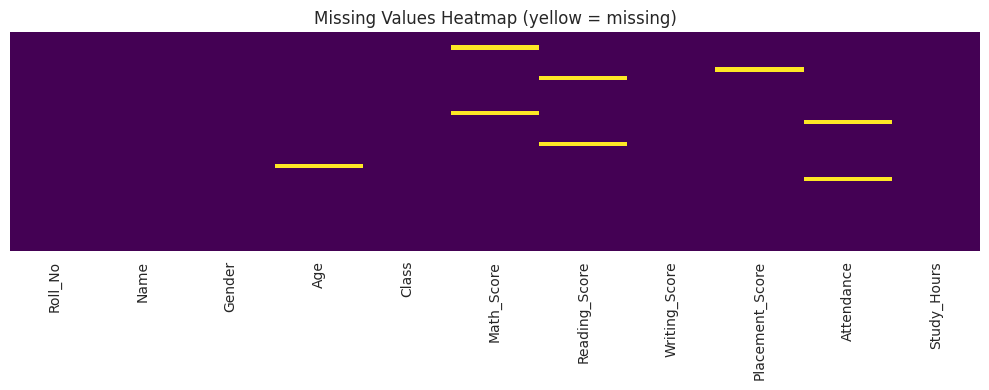

In [7]:
# Visualize missing values as a heatmap.
# Yellow stripes mark NaN cells, making the missing pattern easy to spot.
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap (yellow = missing)')
plt.tight_layout()
plt.show()

**Strategy for filling missing values:**
- Numeric columns (`Age`, `Math_Score`, `Reading_Score`, `Placement_Score`, `Attendance`) — fill with the **median** (robust to outliers, unlike the mean).

In [8]:
# fillna() replaces NaN. We use the column's median to stay robust to outliers.
# inplace=True modifies the DataFrame directly instead of returning a new one.
numeric_cols_with_na = ['Age', 'Math_Score', 'Reading_Score', 'Placement_Score', 'Attendance']

for col in numeric_cols_with_na:
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)
    print(f"Filled missing {col} with median = {median_val}")

# Verify no missing values remain
print("\nMissing values after filling:")
print(df.isnull().sum())

Filled missing Age with median = 20.0
Filled missing Math_Score with median = 70.0
Filled missing Reading_Score with median = 71.95
Filled missing Placement_Score with median = 26.2
Filled missing Attendance with median = 81.35

Missing values after filling:
Roll_No            0
Name               0
Gender             0
Age                1
Class              0
Math_Score         2
Reading_Score      2
Writing_Score      0
Placement_Score    1
Attendance         2
Study_Hours        0
dtype: int64


/tmp/ipykernel_530/3003184223.py:7: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].fillna(median_val, inplace=True)
/tmp/ipykernel_530/3003184223.py:7: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update th

### 3.2 Inconsistencies

**Inconsistency #1: Gender column has multiple spellings.**

The same value (e.g., "male") appears as `M`, `Male`, `male`, and `MALE`. We must standardize all variants into two clean categories: `Male` and `Female`.

In [9]:
# unique() returns the distinct values present in the column.
print("Unique Gender values BEFORE cleaning:")
print(df['Gender'].unique())

# value_counts() shows how many times each value appears.
print("\nValue counts BEFORE cleaning:")
print(df['Gender'].value_counts())

Unique Gender values BEFORE cleaning:
<StringArray>
['F', 'MALE', 'Female', 'M', 'FEMALE', 'male', 'female', 'Male']
Length: 8, dtype: str

Value counts BEFORE cleaning:
Gender
MALE      8
FEMALE    8
Female    7
M         7
F         6
female    6
male      5
Male      3
Name: count, dtype: int64


In [10]:
# Step A: convert everything to lowercase using str.lower() and strip whitespace.
df['Gender'] = df['Gender'].str.lower().str.strip()

# Step B: map all male variants to 'Male' and all female variants to 'Female'.
gender_map = {
    'm': 'Male', 'male': 'Male',
    'f': 'Female', 'female': 'Female'
}
df['Gender'] = df['Gender'].map(gender_map)

# Verify
print("Unique Gender values AFTER cleaning:")
print(df['Gender'].unique())
print("\nValue counts AFTER cleaning:")
print(df['Gender'].value_counts())

Unique Gender values AFTER cleaning:
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

Value counts AFTER cleaning:
Gender
Female    27
Male      23
Name: count, dtype: int64


**Inconsistency #2: Out-of-range values.**

We expect:
- `Age` between 15 and 30 (typical college student range)
- `Math_Score`, `Reading_Score`, `Writing_Score`, `Placement_Score` between 0 and 100
- `Attendance` between 0 and 100

Anything outside these ranges is invalid — likely a data-entry error. We replace such values with `NaN` and then re-impute with the median.

In [11]:
# Detect invalid Age values (negative or unrealistically high).
print("Invalid Age values:")
print(df[(df['Age'] < 15) | (df['Age'] > 30)][['Roll_No', 'Name', 'Age']])

# Detect Math_Score values outside 0-100.
print("\nInvalid Math_Score values (>100 or <0):")
print(df[(df['Math_Score'] < 0) | (df['Math_Score'] > 100)][['Roll_No', 'Name', 'Math_Score']])

# Detect Attendance values outside 0-100.
print("\nInvalid Attendance values (>100 or <0):")
print(df[(df['Attendance'] < 0) | (df['Attendance'] > 100)][['Roll_No', 'Name', 'Attendance']])

Invalid Age values:
    Roll_No         Name    Age
5         6  Student_006   -3.0
12       13  Student_013  150.0

Invalid Math_Score values (>100 or <0):
   Roll_No         Name  Math_Score
7        8  Student_008       105.0

Invalid Attendance values (>100 or <0):
    Roll_No         Name  Attendance
2         3  Student_003       105.0
15       16  Student_016       110.0


In [12]:
# Replace out-of-range values with NaN.
# .loc[row_condition, column] is the standard way to assign to a subset of a DataFrame.
df.loc[(df['Age'] < 15) | (df['Age'] > 30), 'Age'] = np.nan
df.loc[(df['Math_Score'] < 0) | (df['Math_Score'] > 100), 'Math_Score'] = np.nan
df.loc[(df['Reading_Score'] < 0) | (df['Reading_Score'] > 100), 'Reading_Score'] = np.nan
df.loc[(df['Writing_Score'] < 0) | (df['Writing_Score'] > 100), 'Writing_Score'] = np.nan
df.loc[(df['Placement_Score'] < 0) | (df['Placement_Score'] > 100), 'Placement_Score'] = np.nan
df.loc[(df['Attendance'] < 0) | (df['Attendance'] > 100), 'Attendance'] = np.nan

# Now re-impute the freshly-introduced NaNs with the column median.
for col in ['Age', 'Math_Score', 'Reading_Score', 'Writing_Score', 'Placement_Score', 'Attendance']:
    df[col].fillna(df[col].median(), inplace=True)

print("After cleaning, summary statistics:")
df.describe()

After cleaning, summary statistics:


/tmp/ipykernel_530/1091935869.py:12: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_530/1091935869.py:12: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to u

,Roll_No,Age,Math_Score,Reading_Score,Writing_Score,Placement_Score,Attendance,Study_Hours
count,50.00000,47.000000,47.000000,48.000000,50.000000,49.000000,46.000000,50.000000
mean,25.50000,19.744681,69.059574,73.325000,70.906000,33.048980,79.952174,8.128200
std,14.57738,1.648030,17.263642,10.925405,12.451545,25.138733,11.433008,7.467002
min,1.00000,17.000000,5.000000,54.700000,48.300000,5.000000,62.200000,0.650000
25%,13.25000,18.000000,63.900000,64.850000,61.025000,15.000000,72.125000,3.935000
50%,25.50000,20.000000,69.700000,71.950000,70.800000,26.200000,79.850000,6.195000
75%,37.75000,21.000000,80.650000,81.225000,80.275000,46.000000,89.350000,10.055000
max,50.00000,22.000000,100.000000,100.000000,100.000000,99.000000,97.600000,42.000000


In [13]:
# Final missing-value check — should be 0 everywhere now.
print("Missing values after full cleaning:")
print(df.isnull().sum())

Missing values after full cleaning:
Roll_No            0
Name               0
Gender             0
Age                3
Class              0
Math_Score         3
Reading_Score      2
Writing_Score      0
Placement_Score    1
Attendance         4
Study_Hours        0
dtype: int64


## Step 4: Detect and Treat Outliers

An **outlier** is a value far from the rest of the data. Outliers can distort statistical summaries and mislead machine-learning models. We use two standard techniques to detect them:

### Boxplot
A boxplot draws a box from Q1 (25th percentile) to Q3 (75th percentile), with a line at the median. Values beyond the "whiskers" are flagged as outliers (shown as dots).

### IQR (Interquartile Range) Method
- IQR = Q3 − Q1
- Lower bound = Q1 − 1.5 × IQR
- Upper bound = Q3 + 1.5 × IQR
- Anything outside [lower, upper] is an outlier.

### 4.1 Visual Detection — Boxplots

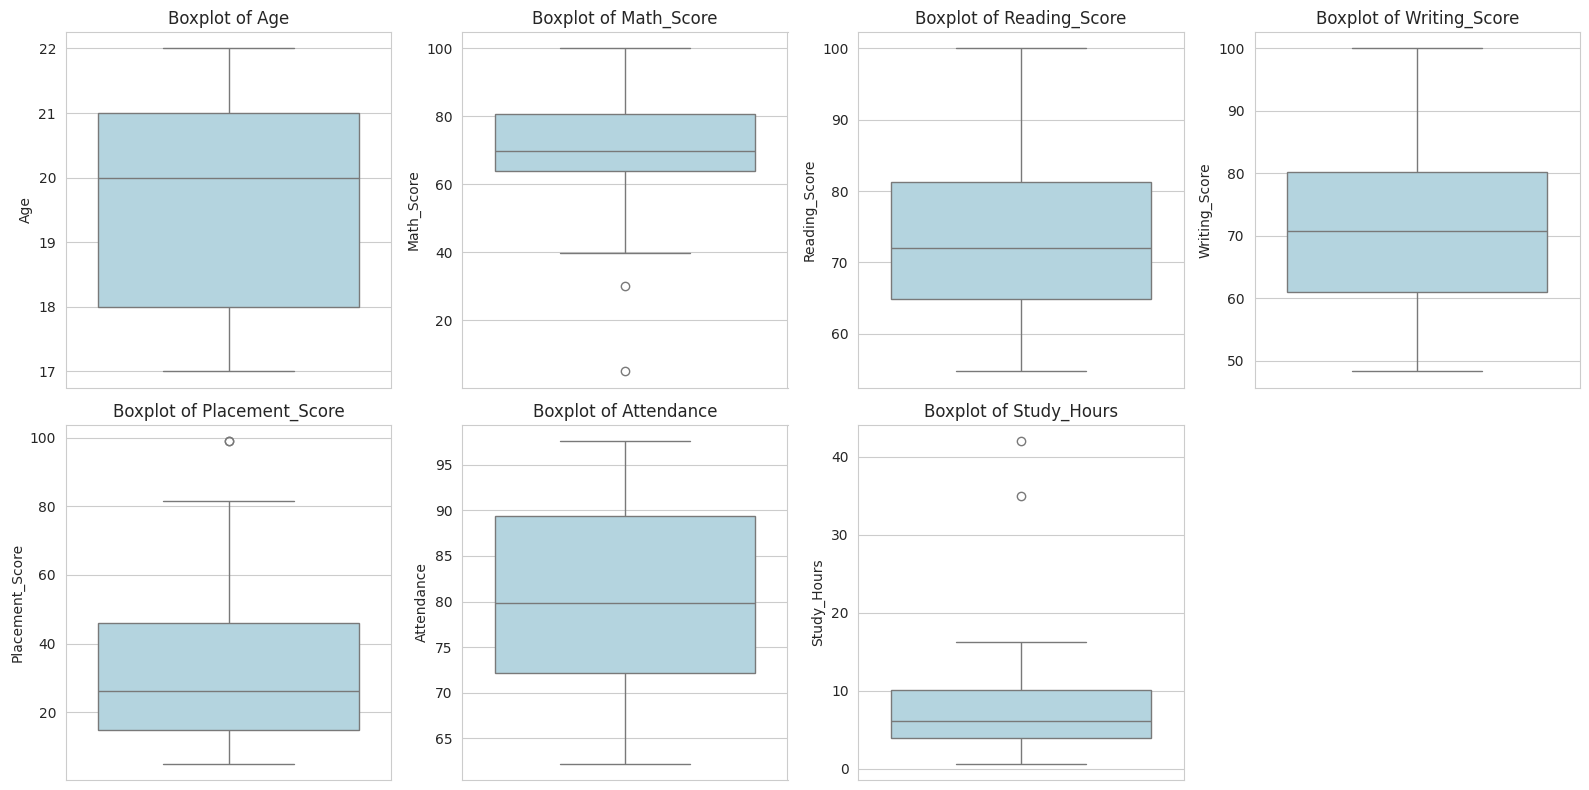

In [14]:
# Plot a boxplot for every numeric column to spot outliers visually.
numeric_columns = ['Age', 'Math_Score', 'Reading_Score', 'Writing_Score',
                   'Placement_Score', 'Attendance', 'Study_Hours']

# Create a 2x4 grid of subplots (one boxplot per numeric column).
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()  # so we can index axes[0], axes[1], ... easily

for i, col in enumerate(numeric_columns):
    sns.boxplot(y=df[col], ax=axes[i], color='lightblue')
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_ylabel(col)

# Hide the unused 8th subplot
axes[7].set_visible(False)

plt.tight_layout()
plt.show()

### 4.2 Numerical Detection — IQR Method

In [15]:
# Function that returns the outlier rows for a given column using the IQR rule.
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)   # 25th percentile
    Q3 = data[column].quantile(0.75)   # 75th percentile
    IQR = Q3 - Q1                       # interquartile range
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Apply to every numeric column and report what we find.
for col in numeric_columns:
    outliers, low, high = detect_outliers_iqr(df, col)
    print(f"{col}: bounds = [{low:.2f}, {high:.2f}], outlier count = {len(outliers)}")

Age: bounds = [13.50, 25.50], outlier count = 0
Math_Score: bounds = [38.77, 105.78], outlier count = 2
Reading_Score: bounds = [40.29, 105.79], outlier count = 0
Writing_Score: bounds = [32.15, 109.15], outlier count = 0
Placement_Score: bounds = [-31.50, 92.50], outlier count = 2
Attendance: bounds = [46.29, 115.19], outlier count = 0
Study_Hours: bounds = [-5.24, 19.23], outlier count = 2


### 4.3 Treating Outliers — Capping (Winsorization)

We **cap** outliers instead of dropping rows. Capping replaces values above the upper bound with the upper bound, and values below the lower bound with the lower bound. This preserves all 50 records — important for a small dataset.

In [16]:
# np.where(condition, value_if_true, value_if_false) is a vectorized if/else.
# We use it to replace each outlier with the nearest IQR bound.

def cap_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # Cap values above the upper bound to upper_bound; below the lower bound to lower_bound.
    data[column] = np.where(data[column] > upper_bound, upper_bound, data[column])
    data[column] = np.where(data[column] < lower_bound, lower_bound, data[column])
    return data

# Apply capping to every numeric column.
for col in numeric_columns:
    df = cap_outliers_iqr(df, col)

# Re-check: outlier count should now be 0 everywhere.
print("After capping, outlier counts:")
for col in numeric_columns:
    outliers, _, _ = detect_outliers_iqr(df, col)
    print(f"  {col}: {len(outliers)}")

After capping, outlier counts:
  Age: 0
  Math_Score: 0
  Reading_Score: 0
  Writing_Score: 0
  Placement_Score: 0
  Attendance: 0
  Study_Hours: 0


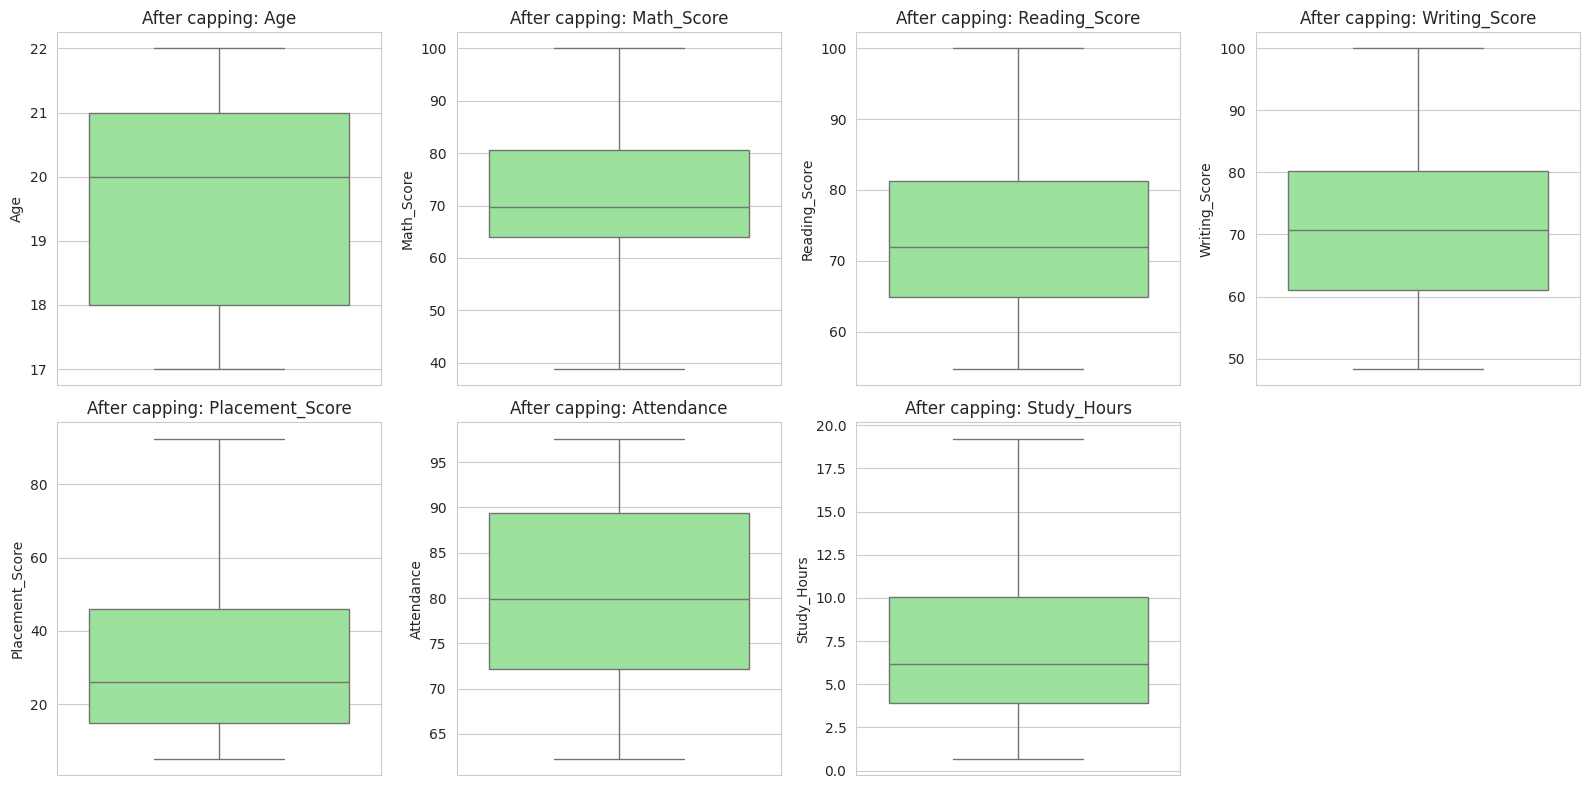

In [17]:
# Boxplots after capping — boxes should look much tidier with no outlier dots.
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_columns):
    sns.boxplot(y=df[col], ax=axes[i], color='lightgreen')
    axes[i].set_title(f'After capping: {col}')

axes[7].set_visible(False)
plt.tight_layout()
plt.show()

### Alternative: Z-Score Method

The **Z-score** of a value is `(value − mean) / std_dev`. A common rule is: if `|z| > 3`, the value is an outlier. This works best for roughly normal distributions.

We show this for reference even though we already used IQR above.

In [18]:
# stats.zscore returns the z-score of each element in the column.
# We take the absolute value and check which exceed 3.
z_scores = np.abs(stats.zscore(df[numeric_columns]))

# Build a small summary: for each column, count rows where |z| > 3.
z_outliers = (z_scores > 3).sum()
print("Outlier counts by Z-score (|z| > 3):")
print(z_outliers)

Outlier counts by Z-score (|z| > 3):
0


## Step 5: Data Transformation

We chose `Study_Hours` for transformation because its distribution is **right-skewed** (a long right tail with a few very large values). Right-skewed data violates the assumption of normality that many statistical methods rely on.

### Why log transform?
- Compresses the long right tail
- Pulls extreme values closer to the rest of the data
- Often turns a right-skewed distribution into a roughly normal one
- Helpful for linear regression, t-tests, ANOVA, and other techniques that assume normality

### 5.1 Original Distribution

Original Study_Hours skewness: 0.7516


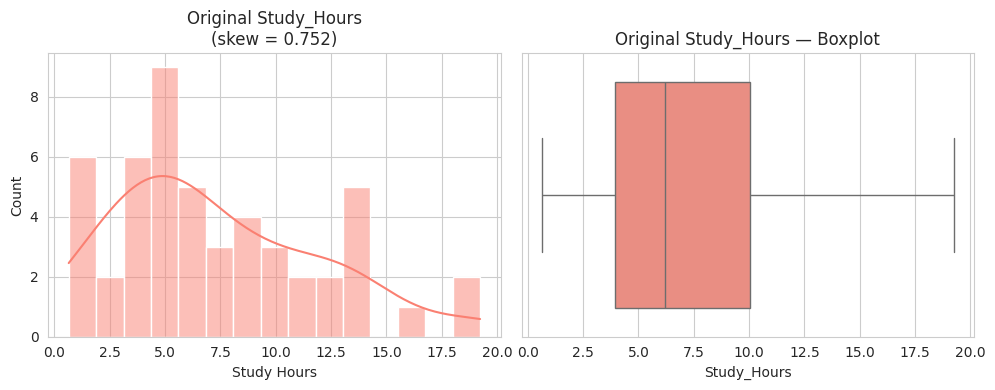

In [19]:
# skew() returns a number describing asymmetry:
#   skew == 0 -> symmetric (normal)
#   skew > 0  -> right-skewed (tail on the right)
#   skew < 0  -> left-skewed
original_skew = df['Study_Hours'].skew()
print(f"Original Study_Hours skewness: {original_skew:.4f}")

# Plot the histogram + kernel density curve.
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['Study_Hours'], kde=True, color='salmon', bins=15)
plt.title(f'Original Study_Hours\n(skew = {original_skew:.3f})')
plt.xlabel('Study Hours')

# Boxplot beside it for a different view of the skew.
plt.subplot(1, 2, 2)
sns.boxplot(x=df['Study_Hours'], color='salmon')
plt.title('Original Study_Hours — Boxplot')
plt.tight_layout()
plt.show()

### 5.2 Apply Log Transformation

In [20]:
# np.log1p(x) computes log(1 + x). We use log1p instead of plain log because:
#   - log(0) is undefined (-infinity); log1p(0) = 0, so it handles zeros safely.
#   - Study_Hours could conceivably be 0 for a student who studied nothing.
df['Study_Hours_Log'] = np.log1p(df['Study_Hours'])

# Re-measure skewness on the transformed column.
new_skew = df['Study_Hours_Log'].skew()
print(f"After log transformation, skewness = {new_skew:.4f}")
print(f"(Skewness moved from {original_skew:.4f} toward 0 — closer to normal)")

df[['Study_Hours', 'Study_Hours_Log']].head(10)

After log transformation, skewness = -0.4553
(Skewness moved from 0.7516 toward 0 — closer to normal)


,Study_Hours,Study_Hours_Log
0,7.49,2.138889
1,9.20,2.322388
2,10.94,2.479894
3,3.37,1.474763
4,2.84,1.345472
5,12.33,2.590017
6,13.88,2.700018
7,3.92,1.593309
8,4.98,1.788421
9,11.72,2.543176


### 5.3 Compare Before and After

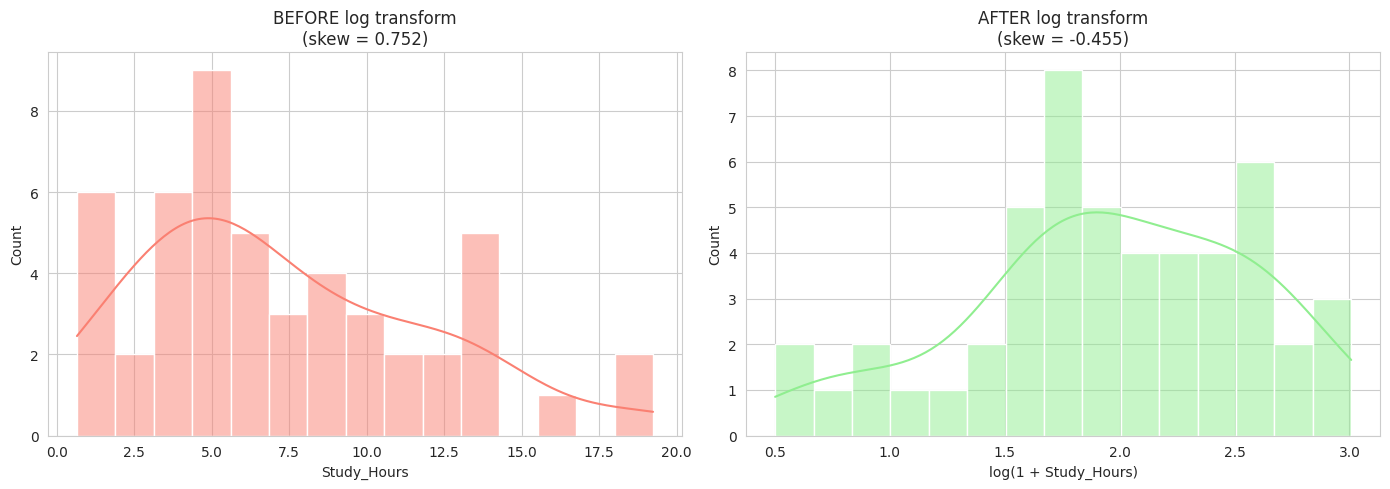

In [21]:
# Plot the original and transformed distributions side by side.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# BEFORE — visibly right-skewed
sns.histplot(df['Study_Hours'], kde=True, color='salmon', bins=15, ax=axes[0])
axes[0].set_title(f'BEFORE log transform\n(skew = {original_skew:.3f})')
axes[0].set_xlabel('Study_Hours')

# AFTER — much more symmetric (closer to normal)
sns.histplot(df['Study_Hours_Log'], kde=True, color='lightgreen', bins=15, ax=axes[1])
axes[1].set_title(f'AFTER log transform\n(skew = {new_skew:.3f})')
axes[1].set_xlabel('log(1 + Study_Hours)')

plt.tight_layout()
plt.show()

### 5.4 Other Common Transformations (For Reference)

Different problems call for different transformations:

| Transformation | When to use |
|----------------|-------------|
| `np.log1p(x)` | Right-skewed positive data — what we used above |
| `np.sqrt(x)` | Mild right skew, count data |
| `1 / x` | Strong right skew (more aggressive than log) |
| `x ** 2` | Left-skewed data |
| Min-Max scaling | Rescale to [0, 1] without changing distribution shape |
| Standardization (z-score) | Center on 0 with std-dev 1 — for normally distributed features |

In [22]:
# Demonstrate Min-Max scaling — rescales Study_Hours to [0, 1].
# Formula: (x - min) / (max - min)
df['Study_Hours_MinMax'] = (df['Study_Hours'] - df['Study_Hours'].min()) / \
                            (df['Study_Hours'].max() - df['Study_Hours'].min())

# Demonstrate Standardization (Z-score scaling) — mean=0, std=1.
# Formula: (x - mean) / std
df['Study_Hours_Standardized'] = (df['Study_Hours'] - df['Study_Hours'].mean()) / df['Study_Hours'].std()

# Skewness, mean, and standard deviation for each version.
comparison = pd.DataFrame({
    'Original':       [df['Study_Hours'].skew(),       df['Study_Hours'].mean(),       df['Study_Hours'].std()],
    'Log':            [df['Study_Hours_Log'].skew(),   df['Study_Hours_Log'].mean(),   df['Study_Hours_Log'].std()],
    'Min-Max':        [df['Study_Hours_MinMax'].skew(),df['Study_Hours_MinMax'].mean(),df['Study_Hours_MinMax'].std()],
    'Standardized':   [df['Study_Hours_Standardized'].skew(), df['Study_Hours_Standardized'].mean(), df['Study_Hours_Standardized'].std()],
}, index=['Skewness', 'Mean', 'Std Dev']).round(4)

print("Comparison of transformations:")
comparison

Comparison of transformations:


,Original,Log,Min-Max,Standardized
Skewness,0.7516,-0.4553,0.7516,0.7516
Mean,7.3576,1.9527,0.3609,-0.0000
Std Dev,4.6941,0.6205,0.2526,1.0000


## Final Cleaned and Transformed DataFrame

In [23]:
# Take a look at the final state of the data.
print("Final shape:", df.shape)
print("\nFinal data types:")
print(df.dtypes)
df.head(10)

Final shape: (50, 14)

Final data types:
Roll_No                       int64
Name                            str
Gender                          str
Age                         float64
Class                           str
Math_Score                  float64
Reading_Score               float64
Writing_Score               float64
Placement_Score             float64
Attendance                  float64
Study_Hours                 float64
Study_Hours_Log             float64
Study_Hours_MinMax          float64
Study_Hours_Standardized    float64
dtype: object


,Roll_No,Name,Gender,Age,Class,Math_Score,Reading_Score,Writing_Score,Placement_Score,Attendance,Study_Hours,Study_Hours_Log,Study_Hours_MinMax,Study_Hours_Standardized
0,1,Student_001,Female,22.0,FY,67.3,59.1,71.2,46.9,66.7,7.49,2.138889,0.368039,0.028206
1,2,Student_002,Male,19.0,SY,63.8,60.1,79.9,15.0,88.5,9.20,2.322388,0.460048,0.392494
2,3,Student_003,Female,20.0,BE,87.7,73.2,70.4,25.5,NaN,10.94,2.479894,0.553672,0.763173
3,4,Student_004,Female,20.0,FY,NaN,66.8,51.0,46.0,97.6,3.37,1.474763,0.146355,-0.849494
4,5,Student_005,Male,17.0,BE,82.5,64.1,82.7,60.6,75.7,2.84,1.345472,0.117837,-0.962402
5,6,Student_006,Female,NaN,FY,74.4,72.0,86.6,49.4,74.1,12.33,2.590017,0.628464,1.059290
6,7,Student_007,Female,21.0,SY,54.4,77.7,78.3,8.7,89.5,13.88,2.700018,0.711864,1.389493
7,8,Student_008,Female,19.0,TY,NaN,68.9,54.6,5.7,73.0,3.92,1.593309,0.175948,-0.732326
8,9,Student_009,Female,21.0,FY,84.6,65.1,57.5,NaN,95.4,4.98,1.788421,0.232984,-0.506510
9,10,Student_010,Male,17.0,BE,81.9,66.9,52.2,16.0,92.6,11.72,2.543176,0.595642,0.929339


In [24]:
# Save the cleaned DataFrame for downstream use.
df.to_csv('academic_performance_cleaned.csv', index=False)
print("Cleaned dataset saved as 'academic_performance_cleaned.csv'")

Cleaned dataset saved as 'academic_performance_cleaned.csv'


## Conclusion

We performed a complete data-wrangling pipeline on the academic performance dataset:

**1. Missing values & inconsistencies**
- Filled missing numeric values with the column median (robust to outliers).
- Standardized `Gender` from 8 different spellings into 2 clean categories.
- Replaced out-of-range values (negative age, age > 100, scores > 100, attendance > 100) with `NaN` and re-imputed.

**2. Outlier detection and treatment**
- Visualized outliers with boxplots.
- Detected outliers numerically using the IQR method (Q1 − 1.5·IQR, Q3 + 1.5·IQR).
- Treated outliers via **capping** (winsorization), preserving all rows.
- Cross-checked with the Z-score method.

**3. Data transformation**
- Applied `log1p` to the right-skewed `Study_Hours` to reduce skewness from a high positive value toward 0, producing a more normal distribution.
- Demonstrated Min-Max scaling and Z-score standardization for completeness.

The cleaned, outlier-treated, transformed DataFrame is now ready for exploratory analysis or machine-learning.